# Capire `vqe_dimer.py` — guida interattiva

Questo notebook spiega il modulo VQE del dimero, con celle eseguibili e slider
interattivi. Risponde in modo operativo a:

1. **Perché il VQE dà un limite superiore** all'energia (principio variazionale).
2. **Come l'estimator calcola** $\langle H\rangle_{\boldsymbol\theta}$.
3. **Come sono fatti i due ansätze** — hardware-efficient (HA) e physically
   motivated (PMA) — e perché il PMA usa molti meno parametri.
4. **Perché il PMA fallisce con $D=0.2$ vicino a $B/J=2$** — il punto fisico centrale.

> **Prerequisiti:** ambiente Qiskit 2.x (>= 2.1) con `numpy`, `scipy`, `matplotlib`;
> `ipywidgets` opzionale. Il file `dimer_exact.py` deve essere nella stessa cartella
> (il VQE ci costruisce sopra).

Il modello è sempre
$$H = J\,(X_1X_2+Y_1Y_2+Z_1Z_2) + b\,(Z_1+Z_2) + D\,(X_1Z_2 - Z_1X_2).$$

## 0. Setup

In [1]:
import numpy as np
from scipy.optimize import minimize

from qiskit.primitives import StatevectorEstimator
from qiskit.circuit.library import n_local
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.quantum_info import Statevector, Operator

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", message=".*default.json.*")

# il VQE si appoggia al benchmark esatto (modulo gia' studiato)
from dimer_exact import (dimer_hamiltonian, exact_sweep,
                         analytic_eigenvalues, magnetization_operator)

try:
    from ipywidgets import interact, interact_manual, FloatSlider, IntSlider, Dropdown
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

print("Setup OK. Slider interattivi:", "si" if HAS_WIDGETS else "no (fallback statico)")


def show_circuit(qc, decompose=True):
    # disegna un circuito; stile esplicito "iqp" evita il warning "default.json not found"
    # (le versioni recenti di Qiskit non includono piu' quel file di stile)
    c = qc.decompose() if decompose else qc
    try:
        display(c.draw("mpl", style="iqp"))
    except Exception:
        print(c.draw())

Setup OK. Slider interattivi: si


## 1. Il principio variazionale

Il VQE si fonda su un teorema elementare: per **qualsiasi** stato normalizzato
$∣\psi\rangle$,
$$\langle\psi∣H∣\psi\rangle \;\geq\; E_0,$$
dove $E_0$ è l'energia del ground state. L'uguaglianza vale solo se $∣\psi\rangle$ è il
ground state. Quindi se parametrizzo una famiglia di stati
$∣\psi(\boldsymbol\theta)\rangle$ e **minimizzo** $\langle H\rangle_{\boldsymbol\theta}$,
mi avvicino a $E_0$ da sopra — non posso mai scendere sotto.

Questo spiega perché nel modulo $\Delta E = E_\text{VQE} - E_0 \geq 0$ sempre (a meno del
rumore numerico): il VQE è un'**ottimizzazione vincolata dal basso**.

Verifico: prendo stati casuali e controllo che la loro energia stia sopra $E_0$.

In [3]:
H = dimer_hamiltonian(b=1.0, J=1.0, D=0.0).to_matrix()
E0 = float(np.linalg.eigvalsh(H)[0])
print(f"E0 (esatto) = {E0:.4f}\n")

rng = np.random.default_rng(0)
for _ in range(6):
    psi = rng.normal(size=4) + 1j * rng.normal(size=4)
    psi /= np.linalg.norm(psi)
    E = float(np.real(psi.conj() @ H @ psi))
    print(f"  stato casuale: <H> = {E:8.4f}   >= E0 ? {E >= E0 - 1e-12}")

E0 (esatto) = -3.0000

  stato casuale: <H> =  -0.2049   >= E0 ? True
  stato casuale: <H> =   1.7769   >= E0 ? True
  stato casuale: <H> =  -1.7083   >= E0 ? True
  stato casuale: <H> =  -0.1731   >= E0 ? True
  stato casuale: <H> =  -0.5054   >= E0 ? True
  stato casuale: <H> =   0.0405   >= E0 ? True


## 2. L'estimator: come si calcola $\langle H\rangle$

Nel ciclo VQE, a ogni iterazione bisogna valutare $\langle\psi(\boldsymbol\theta)∣H∣\psi(\boldsymbol\theta)\rangle$.
Lo fa `StatevectorEstimator` (Qiskit 2.x). Si costruisce un **PUB** (Primitive Unified Bloc):
la tripla `(ansatz, hamiltonian, [params])`. L'estimator assegna i parametri, calcola lo
stato e restituisce il valore di aspettazione in `result[0].data.evs`.

Attenzione: `evs` è un array NumPy anche per un solo valore — serve `.item()` per
ottenere uno scalare Python.

Verifico che l'estimator dia lo stesso risultato del calcolo manuale con `Statevector`.

In [4]:
ansatz = n_local(2, "ry", "cz", entanglement="full", reps=2)
H_op = dimer_hamiltonian(1.0, 1.0, 0.0)
estimator = StatevectorEstimator()

params = np.linspace(0.1, 1.2, ansatz.num_parameters)   # parametri arbitrari

# --- via estimator
pub = (ansatz, H_op, [params])
E_est = estimator.run([pub]).result()[0].data.evs.item()

# --- via Statevector (manuale)
sv = Statevector(ansatz.assign_parameters(params)).data
E_man = float(np.real(sv.conj() @ H_op.to_matrix() @ sv))

print(f"<H> estimator = {E_est:.8f}")
print(f"<H> manuale   = {E_man:.8f}")
print(f"coincidono?     {np.isclose(E_est, E_man)}")

<H> estimator = 0.53250026
<H> manuale   = 0.53250026
coincidono?     True


## 3. L'ansatz hardware-efficient (HA)

L'HA è costruito con `n_local` (la funzione che sostituisce la classe `TwoLocal`,
deprecata in Qiskit 2.1): strati alternati di rotazioni $R_y$ su ogni qubit e gate
entangling $CZ$. È **generico** — non sa nulla della fisica del problema, ma con
abbastanza strati può rappresentare qualunque stato.

Numero di parametri: $2(\text{reps}+1)$. Per `reps=2`: 6 parametri.

Parametri HA (reps=2): 6


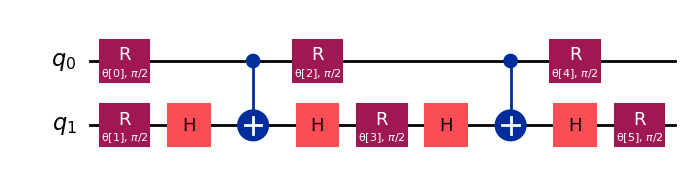

In [5]:
import warnings
warnings.filterwarnings("ignore", message="Style JSON file")

def make_ha_ansatz(reps=2):
    # Ry + CZ, 2*(reps+1) parametri
    return n_local(num_qubits=2, rotation_blocks="ry",
                   entanglement_blocks="cz", entanglement="full", reps=reps)

ha = make_ha_ansatz(reps=2)
print("Parametri HA (reps=2):", ha.num_parameters)
show_circuit(ha)

## 4. L'ansatz physically motivated (PMA)

Il PMA (Crippa et al. 2021) è costruito **sulle simmetrie del problema**. Il blocco
fondamentale agisce su ogni legame $(i,j)$:
$$W_{ij}(\theta) = \text{CNOT}_{ij}\,\big(R_y(\theta)_i\otimes I_j\big)\,\text{CNOT}_{ij}.$$

E lo stato iniziale rispetta la simmetria del ground state atteso:
- $B/J < 2$ (GS = singoletto, $S=0$, $M=0$): si parte dal **singoletto locale**
  $(∣01\rangle-∣10\rangle)/\sqrt2$;
- $B/J \geq 2$ (GS = $∣11\rangle$, $M=-1$): si parte da **$∣11\rangle$**.

Per il dimero ($N=2$, un legame, $K=1$ layer): **1 solo parametro**. Il prezzo di questa
efficienza è che il PMA *conserva* $S$ e $M$ — utile quando il ground state li ha definiti,
problematico quando un termine li rompe (lo vedo in §7).

### Perché si sceglie il riferimento in base a $B/J$?

Il ground state del dimero **cambia natura bruscamente** al livello critico $B/J=2$ (level
crossing): sotto soglia è il singoletto, sopra è $∣11\rangle$ — due stati completamente
diversi, non c'è un singolo riferimento che vada bene ovunque. L'ansatz quindi **sceglie il
ramo** in base al regime, invece di usare un unico circuito che copra continuamente tutto
l'asse $B/J$ (come faccio più avanti nel notebook `confronto_ansatz_entangler.ipynb` con la
rotazione di Givens). Le due scelte sono entrambe legittime; qui la vedo esplicitamente
passo per passo.

Parametri PMA (K=1): 1

PMA sotto soglia (B/J<2), stato iniziale = singoletto:


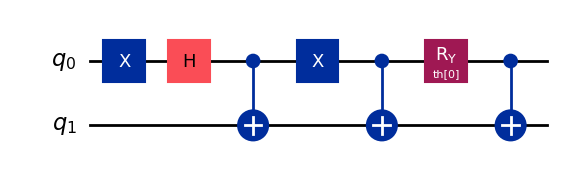

In [6]:
def make_pma_ansatz(b, J=1.0, K=1):
    theta = ParameterVector("th", K)
    qc = QuantumCircuit(2)
    # --- stato iniziale dipendente da B/J
    if b / J < 2.0:
        qc.x(0); qc.h(0); qc.cx(0, 1); qc.x(0)   # singoletto (|01>-|10>)/sqrt(2)
    else:
        qc.x(0); qc.x(1)                          # |11>
    # --- layer W_01(theta)
    for k in range(K):
        qc.cx(0, 1); qc.ry(theta[k], 0); qc.cx(0, 1)
    return qc

print("Parametri PMA (K=1):", make_pma_ansatz(1.0).num_parameters)
print("\nPMA sotto soglia (B/J<2), stato iniziale = singoletto:")
show_circuit(make_pma_ansatz(1.0), decompose=False)

### Derivazione esplicita: perché $X,H,\mathrm{CX},X$ prepara il singoletto

Seguo lo stato passo per passo, partendo da $∣00\rangle$ (convenzione $∣q_0\,q_1\rangle$):

| gate | stato dopo |
|---|---|
| (iniziale) | $∣00\rangle$ |
| $X(q_0)$ | $∣10\rangle$ |
| $H(q_0)$ | $\frac{1}{\sqrt2}\big(∣00\rangle-∣10\rangle\big)$ |
| $\mathrm{CX}(q_0\to q_1)$ | $\frac{1}{\sqrt2}\big(∣00\rangle-∣11\rangle\big)$ &nbsp; (stato di Bell) |
| $X(q_0)$ | $\frac{1}{\sqrt2}\big(∣10\rangle-∣01\rangle\big) = -\frac{1}{\sqrt2}\big(∣01\rangle-∣10\rangle\big)$ |

L'ultimo passo è il **singoletto**, a meno di una fase globale $-1$ (fisicamente
irrilevante: non cambia nessun valore di aspettazione). Ogni gate è fisso, senza parametri:
non è un ansatz variazionale, è una **preparazione deterministica**.

Verifichiamolo stato per stato con il simulatore, non solo all'ultimo passo:

In [7]:
stages = [
    ("iniziale", QuantumCircuit(2)),
]
qc = QuantumCircuit(2); qc.x(0); stages.append(("X(q0)", qc.copy()))
qc.h(0);                stages.append(("H(q0)", qc.copy()))
qc.cx(0, 1);             stages.append(("CX(q0->q1)", qc.copy()))
qc.x(0);                 stages.append(("X(q0)", qc.copy()))

for label, circ in stages:
    sv = Statevector(circ).data
    print(f"{label:14s}  {np.round(sv.real, 3)}  {'(complesso!)' if np.any(np.abs(sv.imag)>1e-9) else ''}")

singlet = np.array([0, 1, -1, 0]) / np.sqrt(2)
print("\nsingoletto atteso (a meno di fase globale):", singlet)

iniziale        [1. 0. 0. 0.]  
X(q0)           [0. 1. 0. 0.]  
H(q0)           [ 0.707 -0.707  0.    -0.   ]  
CX(q0->q1)      [ 0.707  0.     0.    -0.707]  
X(q0)           [ 0.     0.707 -0.707 -0.   ]  

singoletto atteso (a meno di fase globale): [ 0.          0.70710678 -0.70710678  0.        ]


**Verifica dello stato iniziale.** Controllo che la preparazione sotto soglia dia
davvero il singoletto $(∣01\rangle-∣10\rangle)/\sqrt2$, cioè il vettore $[0,\,+0.707,\,-0.707,\,0]$
nella base $∣00\rangle,∣01\rangle,∣10\rangle,∣11\rangle$.

In [8]:
qc0 = QuantumCircuit(2)
qc0.x(0); qc0.h(0); qc0.cx(0, 1); qc0.x(0)
sv0 = Statevector(qc0).data
print("Stato iniziale PMA (B/J<2):", np.round(sv0.real, 3))
print("E' il singoletto? ",
      np.allclose(sv0, np.array([0, 1, -1, 0]) / np.sqrt(2)) or
      np.allclose(sv0, -np.array([0, 1, -1, 0]) / np.sqrt(2)))

Stato iniziale PMA (B/J<2): [ 0.     0.707 -0.707 -0.   ]
E' il singoletto?  True


### Perché basta 1 parametro: la struttura a blocchi di $W_{01}(\theta)$

Il blocco $W_{01}(\theta) = \mathrm{CX}\cdot R_y(\theta)_{q_0}\cdot \mathrm{CX}$ **non** è
semplicemente "l'identità fuori dal settore $M=0$" come si potrebbe pensare. È qualcosa di più
preciso: la sua matrice $4\times4$ è **diagonale a blocchi**, con la **stessa** rotazione
(stesso angolo $\theta$) che agisce **sia** su $\{∣01\rangle,∣10\rangle\}$ **sia** su
$\{∣00\rangle,∣11\rangle\}$, **senza mai farli comunicare**:
$$W_{01}(\theta) = \begin{pmatrix} R(\theta) & 0 \\ 0 & R(\theta)\end{pmatrix}
\quad\text{nei due sottospazi } \{∣00\rangle,∣11\rangle\} \text{ e } \{∣01\rangle,∣10\rangle\}.$$

Verifichiamolo stampando la matrice esplicita:

In [9]:
theta_test = 0.7
qc_W = QuantumCircuit(2); qc_W.cx(0, 1); qc_W.ry(theta_test, 0); qc_W.cx(0, 1)
U = Operator(qc_W).data
np.set_printoptions(precision=3, suppress=True)
print("Matrice di W(theta), base |00>,|01>,|10>,|11>:")
print(U.real)

c, s = np.cos(theta_test/2), np.sin(theta_test/2)
print(f"\ncos(theta/2)={c:.3f}  sin(theta/2)={s:.3f}  -> compaiono su ENTRAMBI i blocchi diagonali")

Matrice di W(theta), base |00>,|01>,|10>,|11>:
[[ 0.939  0.     0.    -0.343]
 [ 0.     0.939  0.343  0.   ]
 [ 0.    -0.343  0.939  0.   ]
 [ 0.343  0.     0.     0.939]]

cos(theta/2)=0.939  sin(theta/2)=0.343  -> compaiono su ENTRAMBI i blocchi diagonali


**Perché questo spiega tutto.** Il blocco non fa uscire lo stato dal sottospazio invariante
in cui lo hai messo la preparazione iniziale:
- se parti dal **singoletto** (ampiezza solo su $\{∣01\rangle,∣10\rangle\}$), il blocco ti
  fa scorrere dentro *quel* sottospazio (dal singoletto verso il tripletto $M=0$ e viceversa);
- se parti da $∣11\rangle$ (ampiezza solo su $\{∣00\rangle,∣11\rangle\}$), il blocco ti fa
  scorrere dentro *quell'altro* sottospazio.

I due sottospazi non si mescolano mai fra loro **perché la matrice è a blocchi**, ma il
blocco **non** è l'identità su nessuno dei due — ruota entrambi, con lo stesso angolo. Ecco
perché **un solo parametro $\theta$** basta per esplorare correttamente entrambi i rami: non
servono due parametri separati, perché una volta scelto il ramo dalla preparazione, la stessa
rotazione riparametrizza correttamente qualunque dei due sottospazi ti serva.

**Confronto con la rotazione di Givens "vera".** Nel notebook `confronto_ansatz_entangler.ipynb`
uso invece un blocco che è **l'identità** su $\{∣00\rangle,∣11\rangle\}$ (li lascia fermi
del tutto), non un'altra rotazione con lo stesso angolo. Sono due decomposizioni diverse della
stessa idea — "un solo parametro per il settore $M=0$" — con proprietà leggermente diverse:
quella di questo notebook richiede di scegliere il ramo giusto in partenza (perché ruoterebbe
anche l'altro sottospazio se ci fosse ampiezza lì); quella di Givens sarebbe "sicura" anche
partendo da una sovrapposizione dei due settori. Nessuna delle due è più corretta: sono scelte
di implementazione diverse dello stesso principio fisico.

## 5. Il loop di ottimizzazione

Il ciclo VQE è quantistico-classico: l'estimator (quantistico) valuta $\langle H\rangle$,
`scipy.optimize.minimize` (classico) aggiorna i parametri. La funzione obiettivo è proprio
l'energia.

Uso **più partenze casuali** (`n_restarts`) e tengo il minimo: il landscape
variazionale ha minimi locali, e una singola partenza può restare intrappolata. È il motivo
per cui nel pannello "errore" del modulo si vedono oscillazioni — non sono fisica, sono
l'ottimizzatore che a volte si ferma in un minimo locale leggermente più alto.

In [10]:
def vqe_energy(params, ansatz, hamiltonian, estimator):
    # funzione obiettivo per scipy.optimize.minimize
    pub = (ansatz, hamiltonian, [params])
    return float(estimator.run([pub]).result()[0].data.evs.item())


def run_vqe_point(b, J=1.0, D=0.0, ansatz_type="HA", reps=2, K=1,
                  n_restarts=3, seed=42):
    # VQE a un singolo campo b; ritorna e_vqe, e_exact, fidelity, mz_vqe
    rng = np.random.default_rng(seed)
    H_op = dimer_hamiltonian(b, J, D)
    est = StatevectorEstimator()
    ansatz = make_ha_ansatz(reps) if ansatz_type == "HA" else make_pma_ansatz(b, J, K)
    npar = ansatz.num_parameters

    r = exact_sweep([b], J=J, D=D)
    e_exact, gs_exact = float(r["gs_energy"][0]), r["gs_state"][0]
    Mz = magnetization_operator().to_matrix()

    best = np.inf; best_p = None
    for _ in range(n_restarts):
        x0 = rng.uniform(-np.pi, np.pi, npar)
        res = minimize(vqe_energy, x0, args=(ansatz, H_op, est),
                       method="L-BFGS-B", options={"maxiter": 2000, "ftol": 1e-12})
        if res.fun < best:
            best, best_p = res.fun, res.x

    sv = Statevector(ansatz.assign_parameters(best_p)).data
    fid = float(np.abs(sv.conj() @ gs_exact))
    mz  = float(np.real(sv.conj() @ Mz @ sv))
    return {"e_vqe": best, "e_exact": e_exact, "delta_e": best - e_exact,
            "fidelity": fid, "mz_vqe": mz, "n_params": npar}

# esempio: HA a b/J = 1, D = 0
out = run_vqe_point(1.0, ansatz_type="HA")
print(f"HA, b/J=1, D=0:  E_vqe={out['e_vqe']:.6f}  E_exact={out['e_exact']:.6f}"
      f"  dE={out['delta_e']:+.2e}  F={out['fidelity']:.4f}  ({out['n_params']} par)")

HA, b/J=1, D=0:  E_vqe=-3.000000  E_exact=-3.000000  dE=+5.02e-13  F=1.0000  (6 par)


## 6. La fidelity

L'energia dice quanto sei vicino in *valore*; la **fidelity** dice quanto sei vicino in
*stato*:
$$\mathcal F = ∣\langle\psi_0∣\psi(\tilde{\boldsymbol\theta})\rangle∣,$$
con $∣\psi_0\rangle$ il ground state esatto (da `eigh`). $\mathcal F=1$ significa che il VQE
ha trovato esattamente il ground state, non solo la sua energia. Si calcola come modulo
dell'overlap tra i due vettori di stato.

In [11]:
for at in ["HA", "PMA"]:
    o = run_vqe_point(1.0, ansatz_type=at, D=0.0)
    print(f"{at:>3}  b/J=1  D=0:  F = {o['fidelity']:.6f}   ({o['n_params']} parametri)")

 HA  b/J=1  D=0:  F = 1.000000   (6 parametri)
PMA  b/J=1  D=0:  F = 1.000000   (1 parametri)


## 7. Il risultato centrale: HA vs PMA, $D=0$ vs $D=0.2$

Qui si vede il messaggio fisico. Eseguo i due ansätze nei due casi e confronto la
**fidelity** lungo $B/J$ (la metrica più parlante). Uso il modulo `vqe_dimer` per lo
sweep completo — sono le stesse funzioni viste sopra, impacchettate.

Aspettativa:
- **HA** (generico): $\mathcal F=1$ in entrambi i casi.
- **PMA** con $D=0$: $\mathcal F=1$ con 1 solo parametro.
- **PMA** con $D=0.2$: **crolla vicino a $B/J=2$**, perché impone $M$ definito mentre il
  vero ground state dell'anticrossing è una miscela singoletto/tripletto $M=-1$.

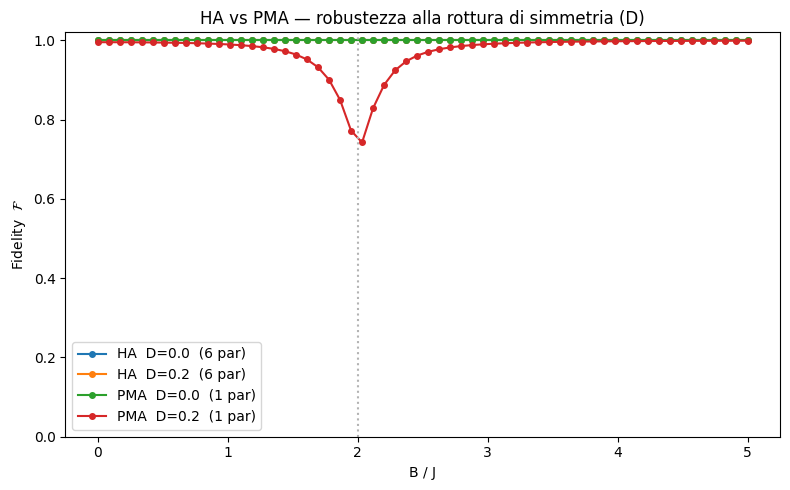

In [12]:
from vqe_dimer import vqe_sweep

b_vals = np.linspace(0.0, 5.0, 60)
configs = [("HA", 0.0, "tab:blue"), ("HA", 0.2, "tab:orange"),
           ("PMA", 0.0, "tab:green"), ("PMA", 0.2, "tab:red")]

plt.figure(figsize=(8, 5))
for at, D, c in configs:
    res = vqe_sweep(b_vals, J=1.0, D=D, ansatz_type=at, n_restarts=3, verbose=False)
    fid = [r["fidelity"] for r in res]
    npar = res[0]["n_params"]
    plt.plot(b_vals, fid, "-o", color=c, ms=4, label=f"{at}  D={D}  ({npar} par)")

plt.axvline(2.0, color="0.7", ls=":")
plt.ylim(0.0, 1.02); plt.xlabel("B / J"); plt.ylabel(r"Fidelity  $\mathcal{F}$")
plt.title("HA vs PMA — robustezza alla rottura di simmetria (D)")
plt.legend(); plt.tight_layout(); plt.show()

### Perché il PMA crolla: la simmetria
Il PMA prepara stati con $M$ definito ($M=0$ sotto soglia, $M=-1$ sopra). Con $D=0$ va
benissimo, perché $H$ conserva $M$ ($[H,S_z]=0$) e il ground state ha $M$ definito. Con
$D\neq0$ invece $[H_D,S_z]\neq0$: il vero ground state in $B/J=2$ è la **miscela**
$\alpha\,∣\text{singoletto}\rangle + \beta\,∣11\rangle$, che il PMA **non può rappresentare**.
La degradazione è massima proprio dove il mescolamento è massimo ($B/J=2$), e svanisce
lontano dalla soglia. È il legame diretto tra l'analisi del termine DM e la scelta
dell'ansatz.

## 8. Esplorazione interattiva

Muovendo gli slider scelgo ansatz, $D$ e $B/J$ e osservo l'energia, errore e fidelity in quel
punto. In particolare **PMA con $D=0.2$ vicino a $B/J=2$** vedro' la fidelity scendere.
(Con `ipywidgets`; altrimenti la cella esegue un esempio statico.)

In [13]:
def explore(ansatz_type="PMA", D=0.2, b_over_J=2.0, reps=2):
    o = run_vqe_point(b_over_J, J=1.0, D=D, ansatz_type=ansatz_type, reps=reps)
    print(f"ansatz={ansatz_type}  D={D}  B/J={b_over_J:.2f}  ({o['n_params']} parametri)")
    print(f"  E_vqe   = {o['e_vqe']:.5f}")
    print(f"  E_exact = {o['e_exact']:.5f}")
    print(f"  Delta E = {o['delta_e']:+.3e}")
    print(f"  Fidelity= {o['fidelity']:.4f}")
    print(f"  <Mz>    = {o['mz_vqe']:+.3f}")

if HAS_WIDGETS:
    interact_manual(explore,
                    ansatz_type=Dropdown(options=["HA", "PMA"], value="PMA"),
                    D=FloatSlider(min=0.0, max=0.6, step=0.05, value=0.2),
                    b_over_J=FloatSlider(min=0.0, max=5.0, step=0.1, value=2.0),
                    reps=IntSlider(min=1, max=4, step=1, value=2))
else:
    explore("PMA", 0.2, 2.0)

interactive(children=(Dropdown(description='ansatz_type', index=1, options=('HA', 'PMA'), value='PMA'), FloatS…

## 9. Riepilogo

1. **Principio variazionale:** $\langle H\rangle_{\boldsymbol\theta}\geq E_0$, quindi il VQE
   approssima il ground state **da sopra** ($\Delta E\geq 0$).
2. **Estimator:** `StatevectorEstimator` valuta $\langle H\rangle$ via il PUB
   `(ansatz, H, [params])`; uso `.evs.item()`.
3. **HA:** generico (`n_local`, Ry+CZ), $2(\text{reps}+1)$ parametri, espressivo ma "costoso".
4. **PMA:** costruito sulle simmetrie (gate $W_{ij}$, stato iniziale a $S,M$ definiti),
   1 parametro per il dimero. Efficientissimo **finché il modello rispetta quelle simmetrie**.
5. **Trade-off (il punto centrale):** con $D=0$ il PMA batte l'HA (1 vs 6 parametri,
   precisione macchina). Con $D=0.2$ il PMA crolla vicino a $B/J=2$ perché conserva $M$
   mentre il termine DM lo rompe; l'HA generico resta a $\mathcal F=1$. Le simmetrie
   nell'ansatz sono un'arma a doppio taglio.